<h1>Diagram of RNN for multi-step prediction</h1>

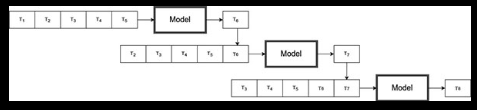

In [9]:
import torch
import torch.nn as nn
import os
import pandas as pd
import matplotlib.pyplot as plt
import copy
import random
import sys
import numpy as np
from sklearn.preprocessing import MinMaxScaler

<h1>Get datasets</h1>

In [6]:
def sliding_window(ts, features):
    X = []
    Y = []

    for i in range(features + 1, len(ts) + 1):
        X.append(ts[i - (features + 1):i - 1])
        Y.append([ts[i - 1]])

    return X, Y


def get_aep_timeseries():
    dir_path = ".."
    df = pd.read_csv(f'{dir_path}/data/AEP_hourly.csv')
    ts = df['AEP_MW'].astype(int).values.reshape(-1, 1)[-3000:]
    return ts


def get_pjme_timeseries():
    dir_path = os.path.dirname(os.path.realpath(__file__))
    df = pd.read_csv(f'{dir_path}/data/PJME_hourly.csv')
    ts = df['PJME_MW'].astype(int).values.reshape(-1, 1)[-3000:]
    return ts


def get_ni_timeseries():
    dir_path = os.path.dirname(os.path.realpath(__file__))
    df = pd.read_csv(f'{dir_path}/data/NI_hourly.csv')
    ts = df['NI_MW'].astype(int).values.reshape(-1, 1)[-3000:]
    return ts


def get_training_datasets(ts, features, test_len):
    X, Y = sliding_window(ts, features)

    X_train, Y_train, X_test, Y_test = X[0:-test_len],\
                                       Y[0:-test_len],\
                                       X[-test_len:],\
                                       Y[-test_len:]

    train_len = round(len(ts) * 0.7)

    X_train, X_val, Y_train, Y_val = X_train[0:train_len],\
                                     X_train[train_len:],\
                                     Y_train[0:train_len],\
                                     Y_train[train_len:]

    x_train = torch.tensor(data = X_train).float()
    y_train = torch.tensor(data = Y_train).float()

    x_val = torch.tensor(data = X_val).float()
    y_val = torch.tensor(data = Y_val).float()

    x_test = torch.tensor(data = X_test).float()
    y_test = torch.tensor(data = Y_test).float()

    return x_train, x_val, x_test,\
           y_train.squeeze(1), y_val.squeeze(1), y_test.squeeze(1)

<h1>Create RNN model</h1>

Parameters of the model:

- `hidden_size`: integer $h$ representing the size of the hidden state
- `input_size`: integer $C$ representing the dimensionality of the input (can be seen as the number of channels for multivariate time series. For univariate time series it is 1)
- `batch_first`: boolean. If `True`, input and output tensors have dimensions $\in \mathbb{R}^{B \times S \times C}$

where 
- $B$: number of batches
- $S$: number of sequences
- $C$: number of channels (`input_size`)

In [7]:
class RNN(nn.Module):

    def __init__(self,
                 hidden_size,
                 in_size = 1,
                 out_size = 1):
        super(RNN, self).__init__()
        self.rnn = nn.RNN(
            input_size = in_size,
            hidden_size = hidden_size,
            batch_first = True)
        self.fc = nn.Linear(hidden_size, out_size)

    def forward(self, x, h = None):
        out, _ = self.rnn(x, h)
        last_hidden_states = out[:, -1]
        out = self.fc(last_hidden_states)
        return out, last_hidden_states

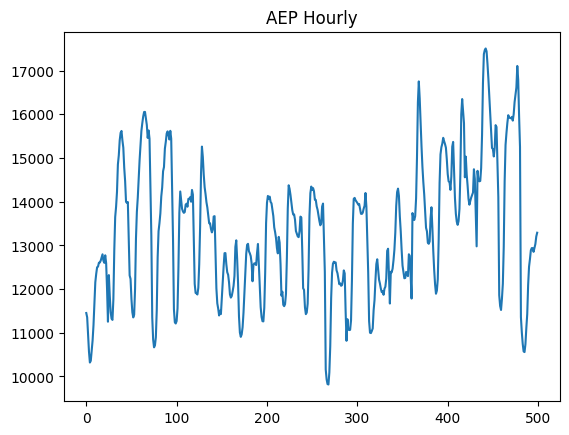

In [8]:
plt.title('AEP Hourly')
plt.plot(get_aep_timeseries()[:500])
plt.show()

<h1>Train RNN model</h1>

<h2>Set random seed for reproducibility</h2>

In [22]:
random.seed(1)
torch.manual_seed(1)

<h2>Parameters</h2>

In [23]:
# length of sliding window
features = 240
# length of test dataset
test_ts_len = 300
# size of RNN hidden state
rnn_hidden_size = 24
# Optimizer learning rate
learning_rate = 0.02

training_epochs = 500

<h2>Prepare datasets</h2>

In [24]:
ts = get_aep_timeseries()
scaler = MinMaxScaler()
scaled_ts = scaler.fit_transform(ts)
x_train, x_val, x_test, y_train, y_val, y_test =\
    get_training_datasets(scaled_ts, features, test_ts_len)

<h3>Dimensions original data</h3>

In [45]:
print(f"ts: {len(ts)}, ts_i: {len(ts[0])}")

ts: 3000, ts_i: 1


<h3>Shapes of tensors</h3>

In [43]:
print(f"x_train: {x_train.shape}, x_val: {x_val.shape}, x_test:{x_test.shape}")
print(f"y_train: {y_train.shape}, y_val: {y_val.shape}, y_test:{y_test.shape}")

x_train: torch.Size([2100, 240, 1]), x_val: torch.Size([360, 240, 1]), x_test:torch.Size([300, 240, 1])
y_train: torch.Size([2100, 1]), y_val: torch.Size([360, 1]), y_test:torch.Size([300, 1])


<h2>Initialize the model</h2>

In [25]:
model = RNN(hidden_size = rnn_hidden_size)
model.train()

RNN(
  (rnn): RNN(1, 24, batch_first=True)
  (fc): Linear(in_features=24, out_features=1, bias=True)
)

<h2>Optimizer and Loss function</h2>

In [26]:
optimizer = torch.optim.Adam(params = model.parameters(), lr = learning_rate)
mse_loss = torch.nn.MSELoss()

<h2>Training</h2>

In [27]:
optimizer = torch.optim.Adam(params = model.parameters(), lr = learning_rate)
mse_loss = torch.nn.MSELoss()

best_model = None
min_val_loss = sys.maxsize

training_loss = []
validation_loss = []

for t in range(training_epochs):

    prediction, _ = model(x_train)
    loss = mse_loss(prediction, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    val_prediction, _ = model(x_val)
    val_loss = mse_loss(val_prediction, y_val)

    training_loss.append(loss.item())
    validation_loss.append(val_loss.item())

    if val_loss.item() < min_val_loss:
        best_model = copy.deepcopy(model)
        min_val_loss = val_loss.item()

    if t % 50 == 0:
        print(f'epoch {t}: train - {round(loss.item(), 4)}, '
              f'val: - {round(val_loss.item(), 4)}')

best_model.eval()
_, h_list = best_model(x_val)

epoch 0: train - 0.377, val: - 0.0866
epoch 50: train - 0.0061, val: - 0.0133
epoch 100: train - 0.0021, val: - 0.0044
epoch 150: train - 0.0018, val: - 0.0034
epoch 200: train - 0.0015, val: - 0.003
epoch 250: train - 0.0014, val: - 0.0027
epoch 300: train - 0.0013, val: - 0.0026
epoch 350: train - 0.0012, val: - 0.0025
epoch 400: train - 0.0012, val: - 0.0024
epoch 450: train - 0.0012, val: - 0.0024


<h2>Evaluate</h2>

It is fundamental to pass **the hidden state to the RNN model** when predicting

In [29]:
h = (h_list[-1, :]).unsqueeze(-2)

predicted = []
for test_seq in x_test.tolist():
    x = torch.Tensor(data = [test_seq])
    # passing hidden state through each iteration
    y, h = best_model(x, h.unsqueeze(-2))
    unscaled = scaler.inverse_transform(np.array(y.item()).reshape(-1, 1))[0][0]
    predicted.append(unscaled)

real = scaler.inverse_transform(y_test.tolist())

In [41]:
x.shape

torch.Size([1, 240, 1])

<h2>Plot</h2>

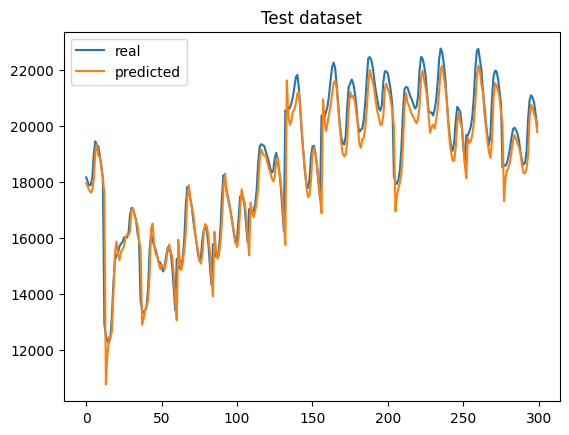

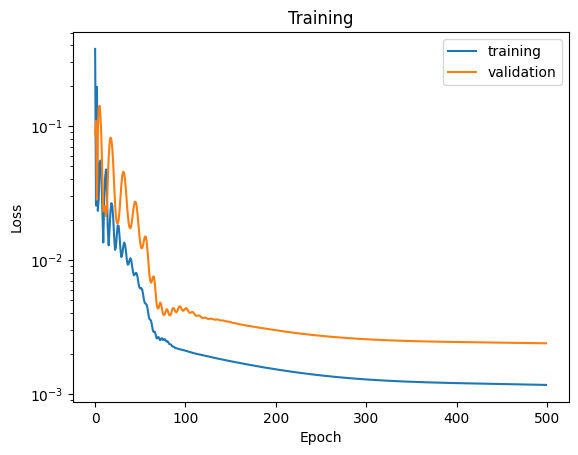

In [30]:
plt.title("Test dataset")
plt.plot(real, label = 'real')
plt.plot(predicted, label = 'predicted')
plt.legend()
plt.show()

plt.title('Training')
plt.yscale('log')
plt.plot(training_loss, label = 'training')
plt.plot(validation_loss, label = 'validation')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()